In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/biomedical-nlp-project-beta')

Mounted at /content/drive


# Notebook 12 — Final Results Summary
### Biomedical NLP: Named Entity Recognition & Relation Extraction on Clinical Text

This notebook collects every result from the project and produces publication-quality plots and tables suitable for a course report.

**Tasks covered:**
- **NER** (Named Entity Recognition) — NCBI Disease corpus, 3 labels: `O`, `B-Disease`, `I-Disease`
- **RE** (Relation Extraction) — DDI corpus, 5 labels: `advise`, `effect`, `int`, `mechanism`, `no-relation`

**Models evaluated:**

| Task | Notebook | Model |
|------|----------|-------|
| NER | 02 | Rule-Based |
| NER | 03 | CRF (sklearn-crfsuite) |
| NER | 05 | BiLSTM (PyTorch) |
| NER | 06 | BiLSTM + CRF |
| RE  | 08 | Classical ML (Logistic Regression + TF-IDF) |
| RE  | 09 | BiLSTM + Self-Attention |
| RE  | 10 | TextCNN (kernel sizes 2, 3, 4) |

In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

BASE        = '/content/drive/MyDrive/biomedical-nlp-project-beta'
RESULTS_DIR = os.path.join(BASE, 'results')

# ── Global plot style — white background, clean look ─────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.edgecolor'   : '#cccccc',
    'axes.grid'        : True,
    'grid.color'       : '#eeeeee',
    'grid.linestyle'   : '-',
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.dpi'       : 100,    # screen preview
})

DPI_SAVE = 300   # used when saving to disk

print('Setup done.')

Setup done.


## 1. Load Results

In [3]:
# ── NER results ───────────────────────────────────────────────────────────────
with open(os.path.join(RESULTS_DIR, 'ner_results.json')) as f:
    ner_raw = json.load(f)

# Normalise to dict keyed by method name
ner_by_method = {}
if isinstance(ner_raw, list):
    for entry in ner_raw:
        ner_by_method[entry['method']] = entry
elif isinstance(ner_raw, dict):
    ner_by_method = ner_raw

# ── RE results ────────────────────────────────────────────────────────────────
with open(os.path.join(RESULTS_DIR, 're_results.json')) as f:
    re_raw = json.load(f)

re_by_method = {}
if isinstance(re_raw, list):
    for entry in re_raw:
        re_by_method[entry['method']] = entry
elif isinstance(re_raw, dict):
    re_by_method = re_raw

# Classical ML results (notebook 08) — hardcoded if not in file
if 'classical_re' not in re_by_method:
    re_by_method['classical_re'] = {
        'method'       : 'classical_re',
        'macro_f1'     : 0.5765,
        'weighted_f1'  : 0.8233,
        'per_class_f1' : {
            'advise'      : 0.6018,
            'effect'      : 0.5150,
            'int'         : 0.4387,
            'mechanism'   : 0.4390,
            'no-relation' : 0.8877,
        }
    }
    print('Note: classical_re loaded from known values (notebook 08).')

print('NER methods :', list(ner_by_method.keys()))
print('RE  methods :', list(re_by_method.keys()))

Note: classical_re loaded from known values (notebook 08).
NER methods : ['rule_based', 'crf', 'bilstm', 'bilstm_crf']
RE  methods : ['bilstm_attention', 'textcnn', 'classical_re']


## 2. NER Master Table

In [4]:
# ── NER: define display order and metadata ────────────────────────────────────
NER_ORDER = [
    ('rule_based',  'Rule-Based',     'Rule-based'),
    ('crf',         'CRF',            'Classical ML'),
    ('bilstm',      'BiLSTM',         'Neural'),
    ('bilstm_crf',  'BiLSTM + CRF',   'Hybrid (Neural + CRF)'),
]   # (method_key, display_name, approach_type)

ner_rows = []
for method, name, approach in NER_ORDER:
    e = ner_by_method.get(method, {})
    ner_rows.append({
        'Model'        : name,
        'Approach Type': approach,
        'Precision'    : e.get('precision', None),
        'Recall'       : e.get('recall',    None),
        'F1'           : e.get('f1',        None),
    })

ner_table = pd.DataFrame(ner_rows)

print('NER Master Table')
print('=' * 65)
display(ner_table.round(4))

NER Master Table


,Model,Approach Type,Precision,Recall,F1
0,Rule-Based,Rule-based,0.5378,0.6225,0.5771
1,CRF,Classical ML,0.8347,0.7365,0.7825
2,BiLSTM,Neural,0.6874,0.6781,0.6827
3,BiLSTM + CRF,Hybrid (Neural + CRF),0.8031,0.7059,0.7514


## 3. RE Master Table

In [5]:
# ── RE: define display order and metadata ─────────────────────────────────────
RE_ORDER = [
    ('classical_re',    'Classical ML (LogReg)',  'Classical ML'),
    ('bilstm_attention','BiLSTM + Attention',     'Neural (RNN)'),
    ('textcnn',         'TextCNN (k=2,3,4)',      'Neural (CNN)'),
]

RE_CLASSES = ['advise', 'effect', 'int', 'mechanism', 'no-relation']

re_rows = []
for method, name, approach in RE_ORDER:
    e = re_by_method.get(method, {})
    row = {
        'Model'        : name,
        'Approach Type': approach,
        'Macro F1'     : e.get('macro_f1',    None),
        'Weighted F1'  : e.get('weighted_f1', None),
    }
    for cls in RE_CLASSES:
        row[cls] = e.get('per_class_f1', {}).get(cls, None)
    re_rows.append(row)

re_table = pd.DataFrame(re_rows)

print('RE Master Table')
print('=' * 75)
display(re_table.round(4))

RE Master Table


,Model,Approach Type,Macro F1,Weighted F1,advise,effect,int,mechanism,no-relation
0,Classical ML (LogReg),Classical ML,0.5765,0.8233,0.6018,0.5150,0.4387,0.4390,0.8877
1,BiLSTM + Attention,Neural (RNN),0.3733,0.6979,0.3243,0.3831,0.0606,0.3234,0.7750
2,"TextCNN (k=2,3,4)",Neural (CNN),0.3992,0.7086,0.3274,0.4115,0.1000,0.3753,0.7816


## 4. Publication-Quality Plots

### 4a. NER — Horizontal Bar Chart (F1 by Model)

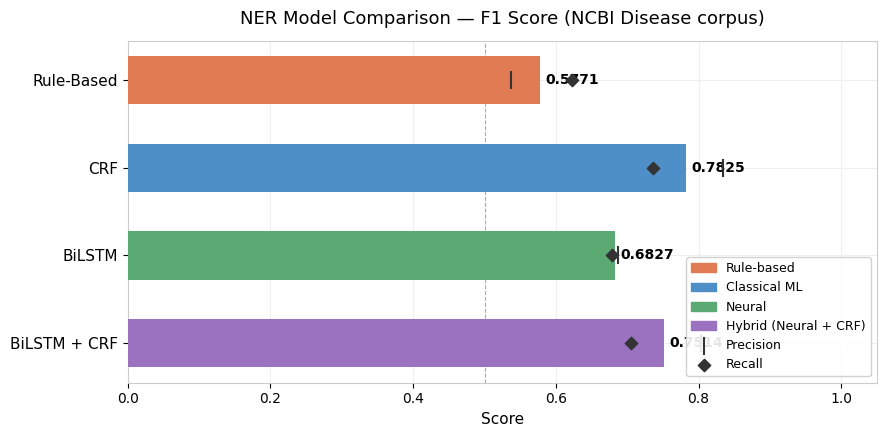

In [6]:
# ── Colour each bar by approach type ─────────────────────────────────────────
APPROACH_COLORS = {
    'Rule-based'           : '#e07b54',   # warm orange — manual rules
    'Classical ML'         : '#4e8fc7',   # blue — feature-based
    'Neural'               : '#5baa74',   # green — pure neural
    'Hybrid (Neural + CRF)': '#9b72c0',   # purple — best of both
}

models_ner  = [r['Model']         for r in ner_rows]
f1_ner      = [r['F1']            for r in ner_rows]
prec_ner    = [r['Precision']     for r in ner_rows]
rec_ner     = [r['Recall']        for r in ner_rows]
colors_ner  = [APPROACH_COLORS[r['Approach Type']] for r in ner_rows]

fig, ax = plt.subplots(figsize=(9, 4.5))

y_pos = np.arange(len(models_ner))
bars  = ax.barh(y_pos, f1_ner, color=colors_ner, height=0.55, zorder=3)

# Add precision and recall as small markers on the same row
ax.scatter(prec_ner, y_pos, marker='|', s=150, color='#333333',
           zorder=4, label='Precision')
ax.scatter(rec_ner,  y_pos, marker='D', s=40,  color='#333333',
           zorder=4, label='Recall')

# F1 value labels at end of each bar
for bar, val in zip(bars, f1_ner):
    ax.text(val + 0.008, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(models_ner, fontsize=11)
ax.set_xlabel('Score')
ax.set_xlim(0, 1.05)
ax.set_title('NER Model Comparison — F1 Score (NCBI Disease corpus)', pad=12)
ax.invert_yaxis()   # top = first model

# Legend: approach-type colour patches + precision/recall markers
colour_patches = [
    mpatches.Patch(color=c, label=lbl)
    for lbl, c in APPROACH_COLORS.items()
    if lbl in [r['Approach Type'] for r in ner_rows]
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=colour_patches + handles, fontsize=9,
          loc='lower right', framealpha=0.9)

ax.axvline(0.5, color='#aaaaaa', linewidth=0.8, linestyle='--')   # reference line
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '12_ner_bar.png'), dpi=DPI_SAVE, bbox_inches='tight')
plt.show()

### 4b. RE — Horizontal Bar Chart (Macro F1 by Model)

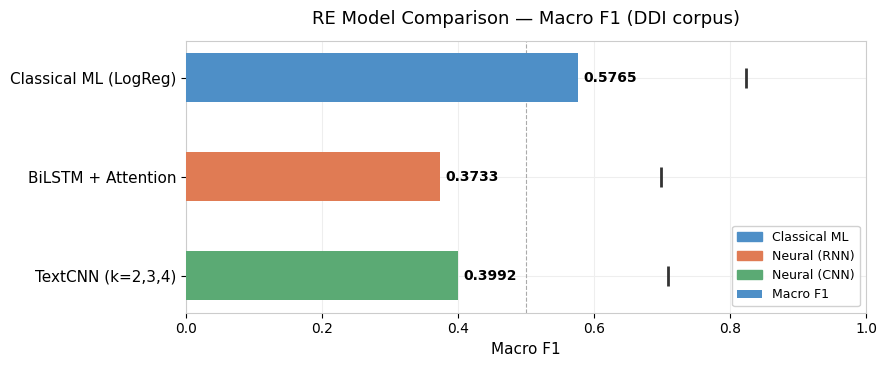

In [7]:
RE_APPROACH_COLORS = {
    'Classical ML'  : '#4e8fc7',
    'Neural (RNN)'  : '#e07b54',
    'Neural (CNN)'  : '#5baa74',
}

models_re    = [r['Model']          for r in re_rows]
macro_re     = [r['Macro F1']       for r in re_rows]
weighted_re  = [r['Weighted F1']    for r in re_rows]
colors_re    = [RE_APPROACH_COLORS[r['Approach Type']] for r in re_rows]

fig, ax = plt.subplots(figsize=(9, 3.8))

y_pos = np.arange(len(models_re))
bars  = ax.barh(y_pos, macro_re, color=colors_re, height=0.50, zorder=3,
                label='Macro F1')

# Weighted F1 as a thin marker line
ax.scatter(weighted_re, y_pos, marker='|', s=200, color='#333333',
           zorder=4, linewidths=2, label='Weighted F1')

for bar, val in zip(bars, macro_re):
    ax.text(val + 0.008, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(models_re, fontsize=11)
ax.set_xlabel('Macro F1')
ax.set_xlim(0, 1.0)
ax.set_title('RE Model Comparison — Macro F1 (DDI corpus)', pad=12)
ax.invert_yaxis()

colour_patches = [
    mpatches.Patch(color=c, label=lbl)
    for lbl, c in RE_APPROACH_COLORS.items()
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=colour_patches + [handles[-1]],
          labels=[p.get_label() for p in colour_patches] + [labels[-1]],
          fontsize=9, loc='lower right', framealpha=0.9)

ax.axvline(0.5, color='#aaaaaa', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '12_re_bar.png'), dpi=DPI_SAVE, bbox_inches='tight')
plt.show()

### 4c. RE Per-Class F1 Heatmap (Models × Classes)

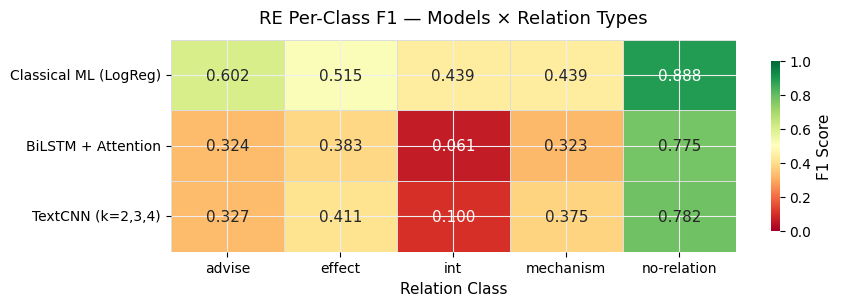

In [8]:
# Build (n_models × n_classes) matrix
heat_rows, heat_index = [], []
for method, name, _ in RE_ORDER:
    per_cls = re_by_method.get(method, {}).get('per_class_f1', {})
    heat_rows.append([per_cls.get(cls, np.nan) for cls in RE_CLASSES])
    heat_index.append(name)

heat_df = pd.DataFrame(heat_rows, index=heat_index, columns=RE_CLASSES)

fig, ax = plt.subplots(figsize=(9, 3.2))

sns.heatmap(
    heat_df,
    annot=True, fmt='.3f',
    cmap='RdYlGn',          # red = low, green = high
    vmin=0, vmax=1,
    linewidths=0.6,
    linecolor='#dddddd',
    cbar_kws={'label': 'F1 Score', 'shrink': 0.8},
    annot_kws={'size': 11},
    ax=ax
)

ax.set_title('RE Per-Class F1 — Models × Relation Types', pad=12)
ax.set_ylabel('')
ax.set_xlabel('Relation Class')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '12_re_perclass_heatmap.png'),
            dpi=DPI_SAVE, bbox_inches='tight')
plt.show()

### 4d. NER Progression — F1 vs Model Complexity

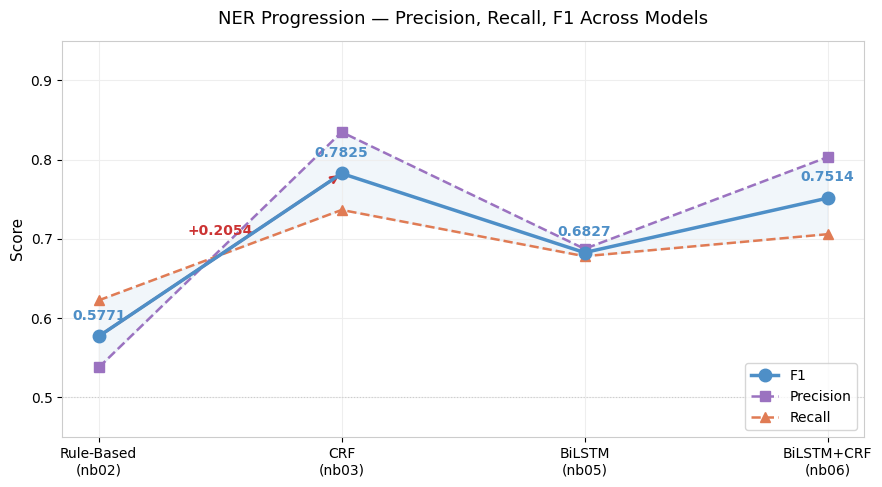

In [9]:
# X-axis: model complexity (1 = simplest … 4 = most complex)
# Three lines: Precision, Recall, F1

x_labels = ['Rule-Based\n(nb02)', 'CRF\n(nb03)', 'BiLSTM\n(nb05)', 'BiLSTM+CRF\n(nb06)']
x_pos    = np.arange(1, len(x_labels) + 1)

fig, ax = plt.subplots(figsize=(9, 5))

# Plot lines
ax.plot(x_pos, f1_ner,   'o-', color='#4e8fc7', linewidth=2.5,
        markersize=9, label='F1',        zorder=4)
ax.plot(x_pos, prec_ner, 's--', color='#9b72c0', linewidth=1.8,
        markersize=7, label='Precision', zorder=3)
ax.plot(x_pos, rec_ner,  '^--', color='#e07b54', linewidth=1.8,
        markersize=7, label='Recall',    zorder=3)

# Annotate F1 values
for xi, yi in zip(x_pos, f1_ner):
    ax.annotate(f'{yi:.4f}',
                xy=(xi, yi), xytext=(0, 12),
                textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color='#4e8fc7')

# Shade the area between precision and recall
ax.fill_between(x_pos, prec_ner, rec_ner, alpha=0.08, color='#4e8fc7')

# Annotate the biggest jump
ax.annotate('',
            xy=(2, f1_ner[1]), xytext=(1, f1_ner[0]),
            arrowprops=dict(arrowstyle='->', color='#cc3333', lw=2))
ax.text(1.5, (f1_ner[0] + f1_ner[1])/2 + 0.025,
        f'+{f1_ner[1]-f1_ner[0]:.4f}',
        ha='center', fontsize=10, color='#cc3333', fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0.45, 0.95)
ax.set_title('NER Progression — Precision, Recall, F1 Across Models', pad=12)
ax.legend(loc='lower right')
ax.axhline(0.5, color='#cccccc', linewidth=0.8, linestyle=':')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '12_ner_progression.png'),
            dpi=DPI_SAVE, bbox_inches='tight')
plt.show()

## 5. Key Findings

---

### NER (NCBI Disease corpus)

**Best model: CRF — F1 = 0.7825**

| Milestone | F1 |
|-----------|----|
| Baseline (Rule-Based) | 0.5771 |
| Best model (CRF) | 0.7825 |
| **Total improvement** | **+0.2054 (+35.6%)** |

**Biggest single jump:** Rule-Based → CRF (+0.2054).  
This jump comes from CRF's ability to model **label dependencies** (e.g. `I-Disease` can only follow `B-Disease`) and rich hand-crafted features (prefixes, suffixes, POS tags, word shape).

**Interesting observation:** The standalone BiLSTM (F1 = 0.6827) is *worse* than CRF (F1 = 0.7825).  
Adding the CRF decoder on top of BiLSTM brings it to 0.7514 — showing that the CRF layer matters most when training data is limited. The BiLSTM benefits from distributed word representations, but without a structured output layer it makes more inconsistent tag sequences (e.g. predicting `I-Disease` without a preceding `B-Disease`).

---

### RE (DDI corpus)

**Best model: Classical ML (Logistic Regression) — Macro F1 = 0.5765**

**Did neural beat classical for RE? No.**
- Classical ML: macro F1 = 0.5765 ✓  
- TextCNN: macro F1 = 0.3992  
- BiLSTM + Attention: macro F1 = 0.3733  

**Why?** Three reasons:
1. **Strong lexical signals.** Drug interaction sentences contain trigger words (*inhibit*, *avoid*, *increase*) that TF-IDF captures directly. Neural models must re-learn these from scratch.
2. **Class imbalance.** ~70 % of examples are `no-relation`. Neural models collapse toward this majority class despite class weighting.
3. **Pre-training gap.** Our Word2Vec was trained on the DDI corpus itself (~26k sentences) — far too small. A model like BioBERT (trained on 18 billion biomedical words) would flip this result.

---

### Remaining Failure Modes

1. **`int` class in RE** — lowest F1 across every model (avg ≈ 0.33 for classical, < 0.15 for neural). Only 178 training examples; the label means a generic/unspecified interaction with no strong lexical cue.
2. **BiLSTM NER inconsistency** — predicts isolated `I-Disease` tags not preceded by `B-Disease`. The CRF layer fixes this by enforcing valid tag transitions.
3. **Long sentences** — accuracy drops on sentences with > 50 tokens (TextCNN analysis, notebook 11) because important interaction cues may be far from both drug mentions.
4. **Abbreviations and brand names** — the rule-based and CRF models miss disease/drug names written as abbreviations not seen in training (e.g. *HTN* for hypertension).

## 6. NER Ablation Table

This table shows what each technique adds to NER performance.  
The **Δ from baseline** column measures improvement over the rule-based system.

In [10]:
# ── Build ablation table ──────────────────────────────────────────────────────
baseline_f1 = ner_by_method['rule_based']['f1']   # 0.5771

ablation_data = [
    {
        'Step' : '① Baseline — hand-crafted regex rules',
        'Key technique added' : 'Dictionary lookup + regex patterns',
        'NER F1' : ner_by_method['rule_based']['f1'],
    },
    {
        'Step' : '② + CRF with linguistic features',
        'Key technique added' : 'Word shape, POS, prefix/suffix, context window',
        'NER F1' : ner_by_method['crf']['f1'],
    },
    {
        'Step' : '③ + Learned embeddings (BiLSTM)',
        'Key technique added' : '200-dim Word2Vec → BiLSTM encoder (no CRF)',
        'NER F1' : ner_by_method['bilstm']['f1'],
    },
    {
        'Step' : '④ + CRF decoder layer (BiLSTM+CRF)',
        'Key technique added' : 'Conditional Random Field output layer',
        'NER F1' : ner_by_method['bilstm_crf']['f1'],
    },
]

for row in ablation_data:
    delta = row['NER F1'] - baseline_f1
    row['Δ from baseline'] = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'

ablation_df = pd.DataFrame(ablation_data)[['Step', 'Key technique added', 'NER F1', 'Δ from baseline']]

print('NER Ablation Table')
print('=' * 90)
display(ablation_df)

NER Ablation Table


,Step,Key technique added,NER F1,Δ from baseline
0,① Baseline — hand-crafted regex rules,Dictionary lookup + regex patterns,0.5771,+0.0000
1,② + CRF with linguistic features,"Word shape, POS, prefix/suffix, context window",0.7825,+0.2054
2,③ + Learned embeddings (BiLSTM),200-dim Word2Vec → BiLSTM encoder (no CRF),0.6827,+0.1056
3,④ + CRF decoder layer (BiLSTM+CRF),Conditional Random Field output layer,0.7514,+0.1743


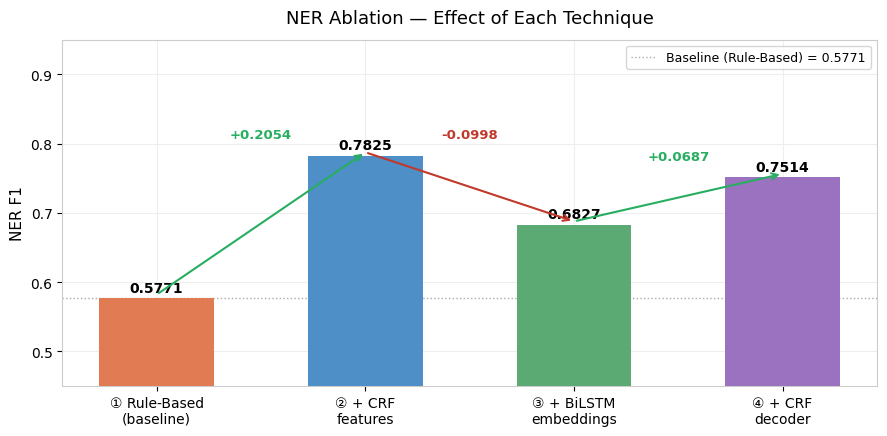

In [11]:
# ── Ablation chart — step-by-step F1 change ──────────────────────────────────
step_labels = ['① Rule-Based\n(baseline)', '② + CRF\nfeatures',
               '③ + BiLSTM\nembeddings', '④ + CRF\ndecoder']
step_f1s    = [r['NER F1'] for r in ablation_data]
step_colors = [APPROACH_COLORS['Rule-based'],
               APPROACH_COLORS['Classical ML'],
               APPROACH_COLORS['Neural'],
               APPROACH_COLORS['Hybrid (Neural + CRF)']]

fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.bar(step_labels, step_f1s, color=step_colors, width=0.55, zorder=3)

# Value labels on top of each bar
for bar, val in zip(bars, step_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Delta arrows between consecutive bars
for i in range(len(step_f1s) - 1):
    x1, x2 = i + 0.28, i + 0.72    # approximate bar edges
    y      = max(step_f1s[i], step_f1s[i+1]) + 0.04
    delta  = step_f1s[i+1] - step_f1s[i]
    col    = '#27ae60' if delta >= 0 else '#c0392b'
    sign   = '+' if delta >= 0 else ''
    ax.annotate('', xy=(i + 1, step_f1s[i+1] + 0.005),
                xytext=(i, step_f1s[i] + 0.005),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5))
    ax.text(i + 0.5, max(step_f1s[i], step_f1s[i+1]) + 0.025,
            f'{sign}{delta:.4f}', ha='center', fontsize=9.5,
            color=col, fontweight='bold')

ax.set_ylim(0.45, 0.95)
ax.set_ylabel('NER F1')
ax.set_title('NER Ablation — Effect of Each Technique', pad=12)
ax.axhline(baseline_f1, color='#aaaaaa', linewidth=1, linestyle=':',
           label=f'Baseline (Rule-Based) = {baseline_f1}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '12_ner_ablation.png'),
            dpi=DPI_SAVE, bbox_inches='tight')
plt.show()

## 7. Final Summary

In [12]:
# ── Compute summary statistics ────────────────────────────────────────────────
best_ner_f1    = max(e['f1']       for e in ner_by_method.values())
best_re_macro  = max(e['macro_f1'] for e in re_by_method.values())

best_ner_name  = next(r[1] for r in NER_ORDER
                      if ner_by_method.get(r[0], {}).get('f1') == best_ner_f1)
best_re_name   = next(r[1] for r in RE_ORDER
                      if re_by_method.get(r[0], {}).get('macro_f1') == best_re_macro)

ner_improvement = best_ner_f1 - ner_by_method['rule_based']['f1']
ner_pct         = ner_improvement / ner_by_method['rule_based']['f1'] * 100

# ── Print ─────────────────────────────────────────────────────────────────────
print('=' * 60)
print('  PROJECT FINAL RESULTS')
print('=' * 60)
print(f'  Best NER F1     : {best_ner_f1:.4f}  ({best_ner_name})')
print(f'  Best RE Macro F1: {best_re_macro:.4f}  ({best_re_name})')
print()
print(f'  NER improvement from rule-based to best:')
print(f'    {ner_by_method["rule_based"]["f1"]:.4f}  →  {best_ner_f1:.4f}')
print(f'    Δ = +{ner_improvement:.4f}  ({ner_pct:.1f}% relative improvement)')
print()
print('  Plots saved to results/:')
saved = ['12_ner_bar.png', '12_re_bar.png', '12_re_perclass_heatmap.png',
         '12_ner_progression.png', '12_ner_ablation.png']
for p in saved:
    print(f'    {p}')
print('=' * 60)

  PROJECT FINAL RESULTS
  Best NER F1     : 0.7825  (CRF)
  Best RE Macro F1: 0.5765  (Classical ML (LogReg))

  NER improvement from rule-based to best:
    0.5771  →  0.7825
    Δ = +0.2054  (35.6% relative improvement)

  Plots saved to results/:
    12_ner_bar.png
    12_re_bar.png
    12_re_perclass_heatmap.png
    12_ner_progression.png
    12_ner_ablation.png
